**EXPERIMENT 9 - DECISION TREE**

Build a Decision Tree model for a below given dataset and evaluate its performance using accuracy, precision, recall, and F1-score. Interpret the results.

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.model_selection import train_test_split

Create Dataset

In [ ]:
data = {
    'Outlook': ['Sunny','Sunny','Overcast','Rain','Rain','Rain','Overcast','Sunny','Sunny','Rain','Sunny','Overcast','Overcast','Rain'],
    'Temp': ['Hot','Hot','Hot','Mild','Cool','Cool','Cool','Mild','Cool','Mild','Mild','Mild','Hot','Mild'],
    'Humidity': ['High','High','High','High','Normal','Normal','Normal','High','Normal','Normal','Normal','High','Normal','High'],
    'Wind': ['Weak','Strong','Weak','Weak','Weak','Strong','Strong','Weak','Weak','Weak','Strong','Strong','Weak','Strong'],
    'PlayTennis': ['No','No','Yes','Yes','Yes','No','Yes','No','Yes','Yes','Yes','Yes','Yes','No']
}

df = pd.DataFrame(data)

Encode categirical values

In [ ]:
le = LabelEncoder()

for column in df.columns:
    df[column] = le.fit_transform(df[column])

# Step 3: Split features and target
X = df.drop('PlayTennis', axis=1)
y = df['PlayTennis']

Train test split

In [ ]:
X = df.drop('PlayTennis', axis=1)
y = df['PlayTennis']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

Train decision tree model and make predictions

In [ ]:
model = DecisionTreeClassifier(criterion='entropy', random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

Evalution Matrics

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

Results

In [ ]:
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

print("\nDetailed Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.6
Precision: 0.6666666666666666
Recall: 0.6666666666666666
F1 Score: 0.6666666666666666

Detailed Report:

              precision    recall  f1-score   support

           0       0.50      0.50      0.50         2
           1       0.67      0.67      0.67         3

    accuracy                           0.60         5
   macro avg       0.58      0.58      0.58         5
weighted avg       0.60      0.60      0.60         5



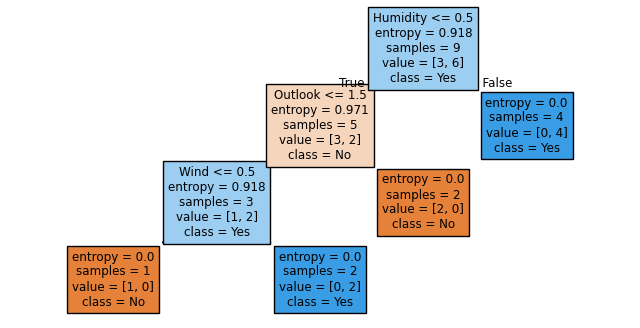

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plot_tree(model, feature_names=X.columns, class_names=['No','Yes'], filled=True)
plt.show()